In [1]:
import os
import sys
import time
import yaml
import pandas as pd
import numpy as np
import re

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']

sys.path.append(os.path.join(LOCAL_PATH, "src/python"))

import data_tools as dt
import writing_tools as wt
from utils import parse_casenum

from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from IPython.core.display import HTML
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

os.environ['LOKY_MAX_CPU_COUNT'] = '1' # because of windows core count warning

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)
with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']
DATA_PATH = local_config['DATA_PATH']
EMBEDDING_DIMENSION = config['EMBEDDING_DIMENSION']

rng = np.random.default_rng(12898)

N_CLUSTERS = 3
N_COMPONENTS = 10


In [2]:
df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data.parquet"))
df_emb = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "embeddings.parquet"))

In [3]:
embeddings = np.array(df_emb['embedding'].tolist())

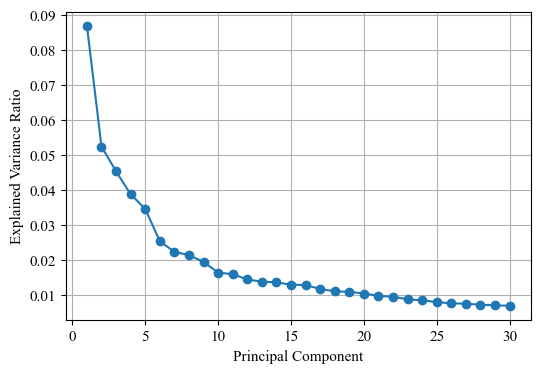

In [4]:
# PCA scree plot

pca = PCA()
pca.fit(embeddings)
explained_variance = pca.explained_variance_ratio_[0:30]
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
#plt.title('Scree Plot of PCA Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_scree_plot.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Scree Plot of PCA Components} \label{fig_scree_plot}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_scree_plot.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note:} Shows how much total variance in the 1,536 dimensional embedding space of the corpus of agenda items is explained by each principal component (up to the first 30).}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_scree_plot.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [5]:
# Reduce embeddings to 10 dimensions
pca = PCA(n_components=N_COMPONENTS)
embeddings_reduced = pca.fit_transform(embeddings)

embeddings_reduced.shape

new_cols = [f'd{k}' for k in range(embeddings_reduced.shape[1])]
dfe = pd.concat([df, pd.DataFrame(embeddings_reduced, columns=new_cols)], axis=1)

In [6]:
# Cluster into 3 clusters using kmeans
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
kmeans.fit(embeddings_reduced)
dfe['cluster'] = kmeans.labels_
dfe['cluster'].value_counts()

cluster
1    377
2    286
0     62
Name: count, dtype: int64

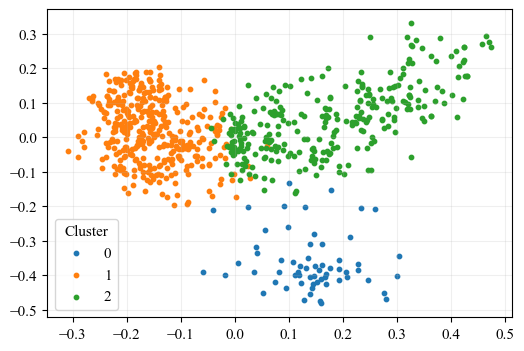

In [7]:
# Scatter plot colored by cluster
plt.figure(figsize=(6, 4))
#colormap = ['blue', 'red', 'green']
for i in range(N_CLUSTERS):
    myx = embeddings_reduced[kmeans.labels_ == i, 0]
    myy = embeddings_reduced[kmeans.labels_ == i, 1]
    #plt.scatter(myx, myy, alpha=0.5, label=f'{i}', color=colormap[i])
    plt.scatter(myx, myy, alpha=1.0, s=10, label=f'{i}')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_clusters.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{PCA Reduced Embeddings with K-Means Clustering} \label{fig_clusters}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_clusters.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note}: Result of K-means clustering with three clusters on the first 10 principal components of the embedding space. The first two dimensions of the 10-dimensional subspace are shown. Each dot is an agenda item.}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_clusters.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [ ]:
# Show random examples from each cluster
for cluster in dfe['cluster'].unique():
    print(f"Cluster {cluster}:")
    cluster_items = dfe[dfe['cluster'] == cluster]
    sample_items = cluster_items.sample(3)
    for idx, row in sample_items.iterrows():
        print("---")
        print(row['agenda_summary'])
    print("======")
    print("")

In [ ]:
# create dataframe with cluter labels and embeddings
df_new = dfa[['date', 'item_no', 'title', 'project_summary', 'cluster']].copy()
new_cols = [f'd{k}' for k in range(embeddings_reduced.shape[1])]
df_new = pd.concat([df_new, pd.DataFrame(embeddings_reduced, columns=new_cols)], axis=1)
df_new.to_csv(
    os.path.join(LOCAL_PATH, 'intermediate_data/cpc', 'agenda_item_with_embeddings.csv'),
    index=False,
    header=True
)

In [ ]:
# create a dataframe with the cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=new_cols)
centroids['cluster'] = range(N_CLUSTERS)
centroids = centroids[['cluster'] + [col for col in centroids.columns if col != 'cluster']]
centroids.to_csv(
    os.path.join(LOCAL_PATH, 'intermediate_data/cpc', 'cluster_centroids.csv'),
    index=False,
    header=True
)

In [ ]:
# create dataframe with cluter labels and embeddings (normalized)
df_new = dfa[['date', 'item_no', 'title', 'project_summary', 'cluster']].copy()
embeddings_reduced_normalized = embeddings_reduced / np.linalg.norm(embeddings_reduced, axis=1, keepdims=True)
new_cols = [f'd{k}' for k in range(embeddings_reduced_normalized.shape[1])]
df_new = pd.concat([df_new, pd.DataFrame(embeddings_reduced_normalized, columns=new_cols)], axis=1)
df_new.to_csv(
    os.path.join(LOCAL_PATH, 'intermediate_data/cpc', 'agenda_item_with_embeddings_normalized.csv'),
    index=False,
    header=True
)

In [ ]:
# create a dataframe with the cluster centroids (normalized)

normalized_centers_ = np.array([
    embeddings_reduced_normalized[kmeans.labels_==0, :].mean(axis=0),
    embeddings_reduced_normalized[kmeans.labels_==1, :].mean(axis=0),
    embeddings_reduced_normalized[kmeans.labels_==2, :].mean(axis=0)
])
normalized_centers_ = normalized_centers_ / np.linalg.norm(normalized_centers_, axis=1, keepdims=True)

centroids_normalized = pd.DataFrame(normalized_centers_, columns=new_cols)
centroids_normalized['cluster'] = range(N_CLUSTERS)
centroids_normalized = centroids_normalized[['cluster'] + [col for col in centroids_normalized.columns if col != 'cluster']]
centroids_normalized.to_csv(
    os.path.join(LOCAL_PATH, 'intermediate_data/cpc', 'cluster_centroids_normalized.csv'),
    index=False,
    header=True
)